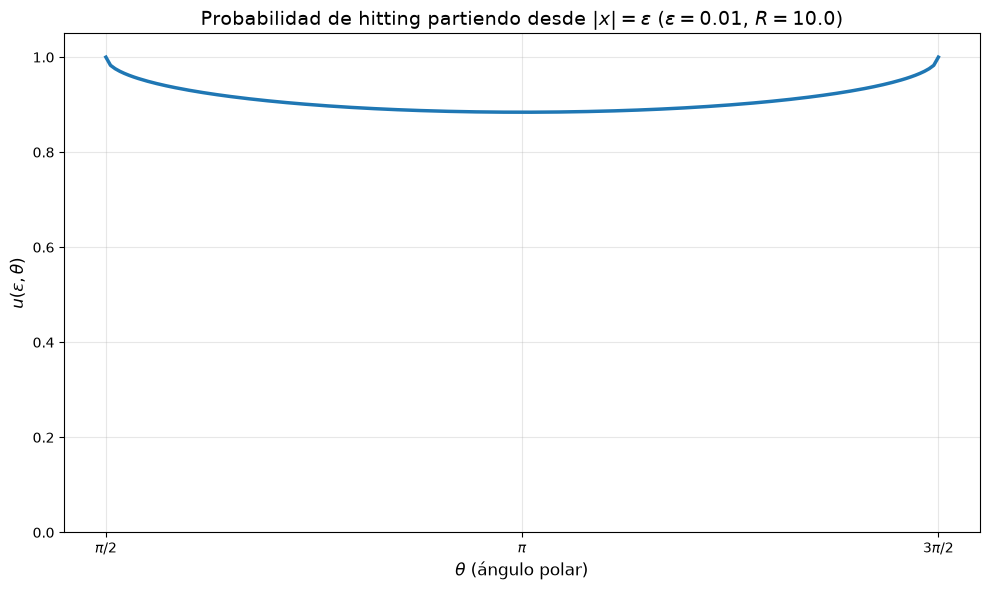

Boundary-integral diagnostics
-----------------------------
N                  = 30
epsilon            = 0.5
R                  = 10.0
||A phi - 1||_inf  = 2.220e-16
cond(A)            = 9.468e+01

u([-5.0, 0.0]) = 0.187269025807

Boundary checks
---------------
u on window       = 1.0
u on outer arc    = 0.0


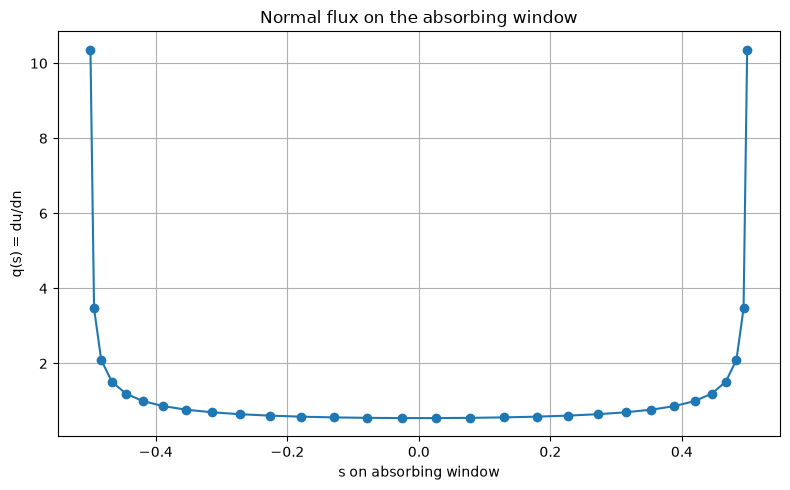

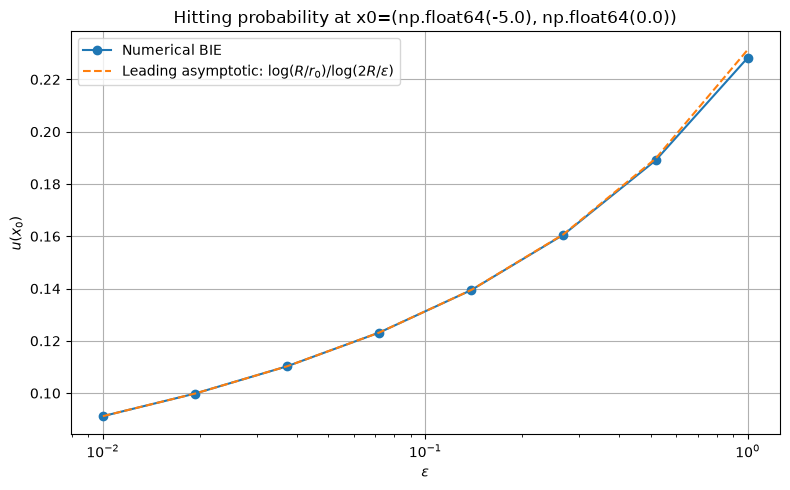

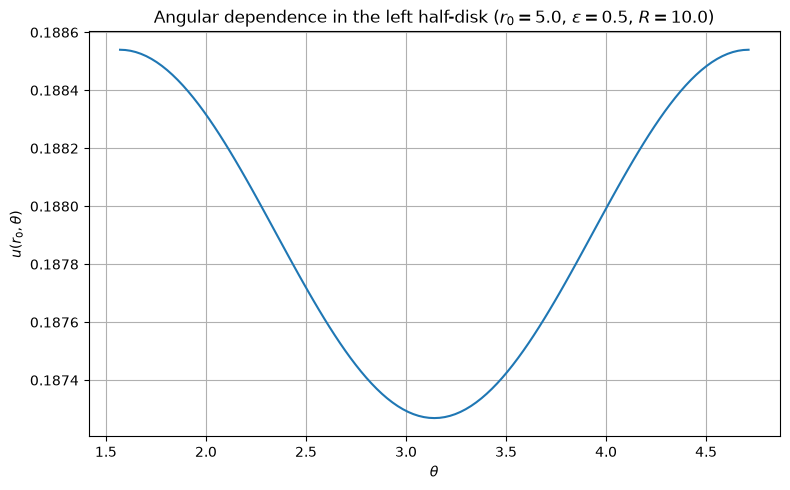

In [5]:
# %% [markdown]
# # Hitting probability in a half-disk with a small absorbing window
#
# Domain:
#   Omega = {(x1,x2): x1 <= 0, x1^2 + x2^2 < R^2}
#
# Boundary conditions for the splitting / hitting probability:
#
#   Delta u = 0                         in Omega
#   u = 1                               on Gamma_a = {(0,s): |s| <= epsilon}
#   u = 0                               on the outer semicircle |x| = R
#   du/dn = 0                           on the remaining flat boundary
#
# Thus u(x) = P_x(tau_window < tau_outer).
#
# We solve a first-kind boundary integral equation for the UNKNOWN NORMAL FLUX
# q = du/dn on Gamma_a.  We do NOT solve for u on Gamma_a, because u=1 there.
#
# The Green function used below satisfies:
#
#   -Delta_y G_H(x,y) = delta_x(y)
#   G_H = 0       on the outer semicircle
#   dG_H/dn = 0   on the whole flat diameter
#
# It is constructed from the Dirichlet Green function of the full disk by
# reflection across x1=0:
#
#   G_H(x,y) = G_B(x,y) + G_B(x,y_reflected).
#
# For y=(0,t) on the flat boundary this simplifies to the explicit expression
# implemented in green_half_disk_boundary_source().
#
# On the absorbing window, Green's representation gives:
#
#   1 = integral_{-epsilon}^{epsilon} G_H((0,s),(0,t)) q(t) dt.
#
# The flux has the endpoint behavior
#
#   q(t) ~ 1/sqrt(epsilon^2-t^2).
#
# We therefore set
#
#   t = epsilon*cos(theta),
#   q(t) = phi(theta)/sqrt(epsilon^2-t^2),
#
# so that q(t) dt = phi(theta) dtheta (up to orientation).  The transformed
# unknown phi is smooth and is discretized by piecewise constants.

# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.linalg import solve


# %% [markdown]
# ## 1. Green function

# %%
def _validate_geometry(epsilon, R):
    if R <= 0:
        raise ValueError("R must be positive.")
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")
    if epsilon >= R:
        raise ValueError("Need 0 < epsilon < R.")


def green_half_disk_boundary_source(x, t, R):
    """
    Mixed Green function G_H(x,(0,t)) for the half-disk.

    Boundary conditions of G_H:
      * Dirichlet on the outer semicircle |x|=R,
      * Neumann on the flat diameter x1=0.

    Parameters
    ----------
    x : array_like, shape (2,)
        Observation point in the left half-disk.
    t : float
        Source coordinate on the flat diameter, y=(0,t).
    R : float
        Disk radius.

    Returns
    -------
    float
        G_H(x,(0,t)).

    Notes
    -----
    For x=(x1,x2), one obtains the stable closed form

        G_H(x,(0,t))
          = (1/pi) log(
                sqrt((x1*t)^2 + (x2*t - R^2)^2)
                /
                (R*sqrt(x1^2 + (x2-t)^2))
            ).

    It is logarithmically singular when x=(0,t).
    """
    x = np.asarray(x, dtype=float)
    if x.shape != (2,):
        raise ValueError("x must have shape (2,).")

    x1, x2 = x

    numerator = np.hypot(x1 * t, x2 * t - R**2)
    denominator = R * np.hypot(x1, x2 - t)

    if denominator == 0.0:
        return np.inf

    return np.log(numerator / denominator) / np.pi


def window_kernel(s, t, R):
    """
    Trace of the mixed Green function on the absorbing window:

        K(s,t)
          = G_H((0,s),(0,t))
          = (1/pi) log((R^2 - s*t)/(R*|s-t|)).

    The singularity at s=t is logarithmic and therefore integrable.
    """
    distance = abs(s - t)
    if distance == 0.0:
        return np.inf

    return np.log((R**2 - s * t) / (R * distance)) / np.pi


# %% [markdown]
# ## 2. Boundary integral equation for the flux

# %%
def assemble_flux_system(N, epsilon, R, epsabs=1e-11, epsrel=1e-11):
    """
    Assemble the collocation system for the transformed flux phi.

    We use:
        t = epsilon*cos(theta),
        q(t) = phi(theta)/sqrt(epsilon^2-t^2),

    and approximate phi by a constant on each theta-panel.

    The integral equation is

        integral_0^pi K(s_i, epsilon*cos(theta)) phi(theta) dtheta = 1.

    Midpoints are used as collocation points.  The logarithmic singularity of
    the diagonal panel is integrated directly by splitting the quadrature
    interval at the collocation point.

    Returns
    -------
    A : ndarray, shape (N,N)
    s_nodes : ndarray, shape (N,)
        Physical collocation points on the window.
    theta_edges : ndarray, shape (N+1,)
    theta_mid : ndarray, shape (N,)
    """
    _validate_geometry(epsilon, R)

    if N < 4:
        raise ValueError("Use N >= 4.")

    theta_edges = np.linspace(0.0, np.pi, N + 1)
    theta_mid = 0.5 * (theta_edges[:-1] + theta_edges[1:])
    s_nodes = epsilon * np.cos(theta_mid)

    A = np.empty((N, N), dtype=float)

    for i, s_i in enumerate(s_nodes):
        for j in range(N):
            a = theta_edges[j]
            b = theta_edges[j + 1]

            def integrand(theta):
                t = epsilon * np.cos(theta)
                return window_kernel(s_i, t, R)

            if i == j:
                # The singularity is logarithmic and integrable.
                c = theta_mid[i]
                left, _ = quad(
                    integrand, a, c,
                    epsabs=epsabs, epsrel=epsrel, limit=100
                )
                right, _ = quad(
                    integrand, c, b,
                    epsabs=epsabs, epsrel=epsrel, limit=100
                )
                A[i, j] = left + right
            else:
                A[i, j], _ = quad(
                    integrand, a, b,
                    epsabs=epsabs, epsrel=epsrel, limit=100
                )

    return A, s_nodes, theta_edges, theta_mid


def solve_window_flux(N, epsilon, R):
    """
    Solve the boundary integral equation for the absorbing-window flux.

    Returns a dictionary containing both the smooth transformed flux phi and
    the physical midpoint values of q.
    """
    A, s_nodes, theta_edges, theta_mid = assemble_flux_system(
        N=N, epsilon=epsilon, R=R
    )

    rhs = np.ones(N)
    phi = solve(A, rhs)

    # Since sqrt(epsilon^2-t^2) = epsilon*sin(theta) for theta in (0,pi):
    q_mid = phi / (epsilon * np.sin(theta_mid))

    residual_inf = np.linalg.norm(A @ phi - rhs, ord=np.inf)

    return {
        "N": N,
        "epsilon": epsilon,
        "R": R,
        "A": A,
        "s_nodes": s_nodes,
        "theta_edges": theta_edges,
        "theta_mid": theta_mid,
        "phi": phi,
        "q_mid": q_mid,
        "residual_inf": residual_inf,
        "condition_number": np.linalg.cond(A),
    }


# %% [markdown]
# ## 3. Evaluate the hitting probability inside the half-disk

# %%
def hitting_probability(x, solution, epsabs=1e-10, epsrel=1e-10):
    """
    Evaluate

        u(x) = integral_{Gamma_a} G_H(x,y) q(y) ds_y

    using the transformed variable theta.
    """
    x = np.asarray(x, dtype=float)

    epsilon = solution["epsilon"]
    R = solution["R"]
    theta_edges = solution["theta_edges"]
    phi = solution["phi"]

    if x.shape != (2,):
        raise ValueError("x must have shape (2,).")

    if x[0] > 1e-12:
        raise ValueError("x is outside the left half-disk: need x1 <= 0.")

    r = np.linalg.norm(x)
    if r > R + 1e-12:
        raise ValueError("x is outside the disk.")

    # Exact boundary values.
    if abs(x[0]) <= 1e-12 and abs(x[1]) <= epsilon:
        return 1.0

    if abs(r - R) <= 1e-12:
        return 0.0

    value = 0.0

    for j, phi_j in enumerate(phi):
        a = theta_edges[j]
        b = theta_edges[j + 1]

        def integrand(theta):
            t = epsilon * np.cos(theta)
            return (
                green_half_disk_boundary_source(x, t, R)
                * phi_j
            )

        panel_value, _ = quad(
            integrand, a, b,
            epsabs=epsabs, epsrel=epsrel, limit=100
        )
        value += panel_value

    return float(value)


# %% [markdown]
# ## 4. Diagnostics and meaningful plots

# %%
def plot_window_flux(solution):
    """
    Plot the physical normal flux q on the window.

    q diverges like 1/sqrt(epsilon^2-s^2) near the two endpoints; this is
    expected for a mixed Dirichlet-Neumann junction.
    """
    s = solution["s_nodes"]
    q = solution["q_mid"]

    order = np.argsort(s)

    plt.figure(figsize=(8, 5))
    plt.plot(s[order], q[order], "o-")
    plt.xlabel("s on absorbing window")
    plt.ylabel("q(s) = du/dn")
    plt.title("Normal flux on the absorbing window")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_probability_vs_epsilon(
    epsilon_values,
    R,
    x0,
    N=30,
):
    """
    Plot the probability at ONE FIXED INTERIOR STARTING POINT x0.

    This is meaningful; plotting max(u) is not, because max(u)=1 by the
    Dirichlet condition on the absorbing window.

    For a fixed point away from the window and epsilon/R -> 0, the leading
    approximation for this centered geometry is

        u(x0) ~ log(R/|x0|) / log(2R/epsilon).
    """
    x0 = np.asarray(x0, dtype=float)
    r0 = np.linalg.norm(x0)

    if r0 <= 0 or r0 >= R:
        raise ValueError("x0 must satisfy 0 < |x0| < R.")
    if x0[0] >= 0:
        raise ValueError("Choose an interior point with x0[0] < 0.")

    epsilon_values = np.asarray(epsilon_values, dtype=float)

    numerical = []
    asymptotic = []

    for epsilon in epsilon_values:
        if epsilon >= r0:
            raise ValueError(
                "For this comparison choose epsilon < |x0|, "
                "so x0 stays away from the window."
            )

        sol = solve_window_flux(N=N, epsilon=epsilon, R=R)
        numerical.append(hitting_probability(x0, sol))
        asymptotic.append(
            np.log(R / r0) / np.log(2.0 * R / epsilon)
        )

    numerical = np.asarray(numerical)
    asymptotic = np.asarray(asymptotic)

    plt.figure(figsize=(8, 5))
    plt.semilogx(epsilon_values, numerical, "o-", label="Numerical BIE")
    plt.semilogx(
        epsilon_values,
        asymptotic,
        "--",
        label=r"Leading asymptotic: $\log(R/r_0)/\log(2R/\epsilon)$",
    )
    plt.xlabel(r"$\epsilon$")
    plt.ylabel(r"$u(x_0)$")
    plt.title(f"Hitting probability at x0={tuple(x0)}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return numerical, asymptotic


def plot_angular_dependence(
    epsilon,
    R,
    r0,
    N=30,
    number_of_angles=121,
):
    """
    Evaluate u on the circle |x|=r0 INSIDE the left half-disk.

    Because Omega is the LEFT half-disk, only
        theta in [pi/2, 3*pi/2]
    belongs to the domain.
    """
    _validate_geometry(epsilon, R)

    if not (epsilon < r0 < R):
        raise ValueError("Choose epsilon < r0 < R.")

    solution = solve_window_flux(N=N, epsilon=epsilon, R=R)

    theta = np.linspace(np.pi / 2.0, 3.0 * np.pi / 2.0, number_of_angles)
    probability = np.empty_like(theta)

    for k, angle in enumerate(theta):
        x = np.array([
            r0 * np.cos(angle),
            r0 * np.sin(angle),
        ])
        probability[k] = hitting_probability(x, solution)

    plt.figure(figsize=(8, 5))
    plt.plot(theta, probability)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$u(r_0,\theta)$")
    plt.title(
        rf"Angular dependence in the left half-disk "
        rf"($r_0={r0}$, $\epsilon={epsilon}$, $R={R}$)"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return theta, probability

def plot_probability_vs_epsilon(
    epsilon_values,
    R,
    x0,
    N=30,
):
    """
    Plot the probability at ONE FIXED INTERIOR STARTING POINT x0.

    This is meaningful; plotting max(u) is not, because max(u)=1 by the
    Dirichlet condition on the absorbing window.

    For a fixed point away from the window and epsilon/R -> 0, the leading
    approximation for this centered geometry is

        u(x0) ~ log(R/|x0|) / log(2R/epsilon).
    """
    x0 = np.asarray(x0, dtype=float)
    r0 = np.linalg.norm(x0)

    if r0 <= 0 or r0 >= R:
        raise ValueError("x0 must satisfy 0 < |x0| < R.")
    if x0[0] >= 0:
        raise ValueError("Choose an interior point with x0[0] < 0.")

    epsilon_values = np.asarray(epsilon_values, dtype=float)

    numerical = []
    asymptotic = []

    for epsilon in epsilon_values:
        if epsilon >= r0:
            raise ValueError(
                "For this comparison choose epsilon < |x0|, "
                "so x0 stays away from the window."
            )

        sol = solve_window_flux(N=N, epsilon=epsilon, R=R)
        numerical.append(hitting_probability(x0, sol))
        asymptotic.append(
            np.log(R / r0) / np.log(2.0 * R / epsilon)
        )

    numerical = np.asarray(numerical)
    asymptotic = np.asarray(asymptotic)

    plt.figure(figsize=(8, 5))
    plt.semilogx(epsilon_values, numerical, "o-", label="Numerical BIE")
    plt.semilogx(
        epsilon_values,
        asymptotic,
        "--",
        label=r"Leading asymptotic: $\log(R/r_0)/\log(2R/\epsilon)$",
    )
    plt.xlabel(r"$\epsilon$")
    plt.ylabel(r"$u(x_0)$")
    plt.title(f"Hitting probability at x0={tuple(x0)}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return numerical, asymptotic


def plot_angular_dependence_on_window_boundary(
    epsilon,
    R,
    N=30,
    number_of_angles=181,
):
    """
    Evalúa u(x) para puntos en la circunferencia |x| = epsilon,
    pero estrictamente dentro del semiplano izquierdo (x1 < 0).

    Parámetros
    ----------
    epsilon : float
        Tamaño de la ventana absorbente y radio de la circunferencia inicial.
    R : float
        Radio del círculo exterior.
    N : int
        Número de paneles en la discretización de la ventana.
    number_of_angles : int
        Número de ángulos a evaluar.
    """
    _validate_geometry(epsilon, R)
    
    # Resolvemos la ecuación integral para el flujo UNA SOLA VEZ
    solution = solve_window_flux(N=N, epsilon=epsilon, R=R)

    # Ángulos en el semiplano izquierdo, ligeramente alejados de los bordes
    # para evitar evaluar justo donde u=1 exactamente.
    theta_min = np.pi / 2.0 + 1e-6
    theta_max = 3.0 * np.pi / 2.0 - 1e-6
    theta = np.linspace(theta_min, theta_max, number_of_angles)
    
    probability = np.empty_like(theta)

    for k, angle in enumerate(theta):
        # Punto sobre la circunferencia de radio epsilon
        x = np.array([
            epsilon * np.cos(angle),
            epsilon * np.sin(angle),
        ])
        # Como x1 < 0, estamos en el interior. La integral es regular.
        probability[k] = hitting_probability(x, solution)

    # Graficamos
    plt.figure(figsize=(10, 6))
    plt.plot(theta, probability, linewidth=2.5)
    plt.xlabel(r"$\theta$ (ángulo polar)", fontsize=12)
    plt.ylabel(r"$u(\epsilon, \theta)$", fontsize=12)
    plt.title(
        rf"Probabilidad de hitting partiendo desde $|x| = \epsilon$ "
        rf"($\epsilon={epsilon}$, $R={R}$)",
        fontsize=14
    )
    plt.xticks(
        [np.pi/2, np.pi, 3*np.pi/2],
        [r'$\pi/2$', r'$\pi$', r'$3\pi/2$']
    )
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

    return theta, probability

# EJECUCIÓN
if __name__ == "__main__":
    R = 10.0
    epsilon = 0.01
    N = 40  # Un poco más de resolución

    # ¡Aquí evaluamos justo en |x| = epsilon!
    theta, prob = plot_angular_dependence_on_window_boundary(
        epsilon=epsilon,
        R=R,
        N=N
    )


# %% [markdown]
# ## 5. Main execution

# %%
if __name__ == "__main__":
    R = 10.0
    epsilon = 0.5
    N = 30

    solution = solve_window_flux(N=N, epsilon=epsilon, R=R)

    print("Boundary-integral diagnostics")
    print("-----------------------------")
    print(f"N                  = {N}")
    print(f"epsilon            = {epsilon}")
    print(f"R                  = {R}")
    print(f"||A phi - 1||_inf  = {solution['residual_inf']:.3e}")
    print(f"cond(A)            = {solution['condition_number']:.3e}")

    x0 = np.array([-5.0, 0.0])
    u0 = hitting_probability(x0, solution)
    print(f"\nu({x0.tolist()}) = {u0:.12f}")

    # Boundary checks:
    print("\nBoundary checks")
    print("---------------")
    print(
        "u on window       =",
        hitting_probability(np.array([0.0, 0.0]), solution),
    )
    print(
        "u on outer arc    =",
        hitting_probability(np.array([-R, 0.0]), solution),
    )

    plot_window_flux(solution)

    eps_values = np.logspace(-2, 0, 8)
    plot_probability_vs_epsilon(
        epsilon_values=eps_values,
        R=R,
        x0=x0,
        N=N,
    )

    plot_angular_dependence(
        epsilon=epsilon,
        R=R,
        r0=5.0,
        N=N,
    )